In [34]:
import ipywidgets as widgets
from IPython.display import display, clear_output
import requests
import base64
from PIL import Image
from io import BytesIO
import json

def generate_3d_ui_ux(user_prompt):
    # Slightly modified prompt to avoid potential filter triggers while maintaining 3D aesthetic
    three_d_prompt = f"3D UI UX design showcase, {user_prompt}, isometric perspective, floating interface elements, soft cinematic lighting, high resolution digital art, tech portfolio style."

    payload = {
        "prompt": three_d_prompt,
        "steps": 4,
        "seed": 12345
    }

    headers = {
        "Authorization": f"Bearer {API_KEY}",
        "Accept": "application/json",
        "Content-Type": "application/json"
    }

    try:
        response = requests.post(invoke_url, headers=headers, json=payload)
        if response.status_code == 200:
            data = response.json()
            artifacts = data.get('artifacts', [])
            if artifacts and len(artifacts) > 0:
                image_b64 = artifacts[0].get('base64', '')

                if not image_b64:
                    print("Error: API returned a success status but the image data was empty. This may be due to content filtering or a model timeout.")
                    return None

                if "," in image_b64:
                    image_b64 = image_b64.split(",")[1]

                image_data = base64.b64decode(image_b64)
                return Image.open(BytesIO(image_data))
            else:
                print("No artifacts found in response.")
                return None
        else:
            print(f"API Error {response.status_code}: {response.text}")
            return None
    except Exception as e:
        print(f"Processing error: {e}")
        return None

# UI Setup
input_text = widgets.Text(placeholder='Describe the UI...', description='UI Prompt:', layout=widgets.Layout(width='70%'))
button = widgets.Button(description='Generate 3D Design', button_style='primary')
output = widgets.Output()

def on_button_clicked(b):
    with output:
        clear_output()
        if input_text.value:
            display("Generating...")
            img = generate_3d_ui_ux(input_text.value)
            clear_output()
            if img: display(img)
        else:
            print("Please enter a prompt.")

button.on_click(on_button_clicked)
display(widgets.VBox([input_text, button, output]))

In [38]:
import requests
import base64
from PIL import Image
from io import BytesIO
import json

# API Configuration
API_KEY = "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"
invoke_url = "https://ai.api.nvidia.com/v1/genai/black-forest-labs/flux.2-klein-4b"

def generate_ui_ux(prompt):
    # Using a high-level professional UI prompt
    enhanced_prompt = f"A high-fidelity web dashboard UI design, {prompt}, dark mode, clean minimal aesthetic, 4k, professional digital art."

    payload = {
        "prompt": enhanced_prompt,
        "steps": 4,
        "seed": 42
    }

    headers = {
        "Authorization": f"Bearer {API_KEY}",
        "Accept": "application/json",
        "Content-Type": "application/json"
    }

    response = requests.post(invoke_url, headers=headers, json=payload)

    if response.status_code != 200:
        print(f"Error {response.status_code}: {response.text}")
        return None

    response_data = response.json()
    image_b64 = response_data['artifacts'][0].get('base64', '')

    if not image_b64:
        print("API Error: Received empty image data. This may be due to content filtering.")
        return None

    try:
        image_data = base64.b64decode(image_b64)
        # Basic check for JPEG or PNG headers
        if not (image_data.startswith(b'\xff\xd8') or image_data.startswith(b'\x89PNG')):
            print("Decoded data is not a valid image. First 20 bytes:", image_data[:20])
            return None

        img = Image.open(BytesIO(image_data))
        display(img)
        return img
    except Exception as e:
        print(f"Image processing error: {e}")
        return None

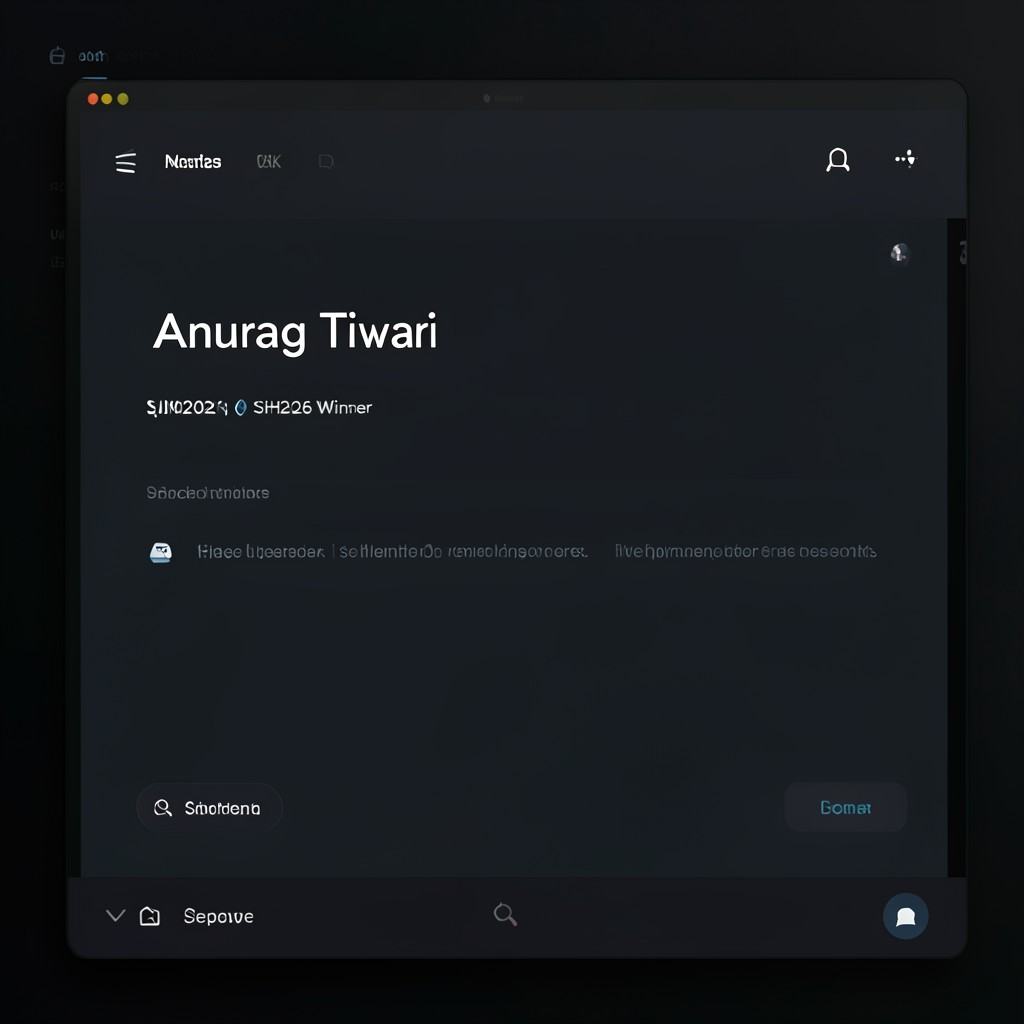

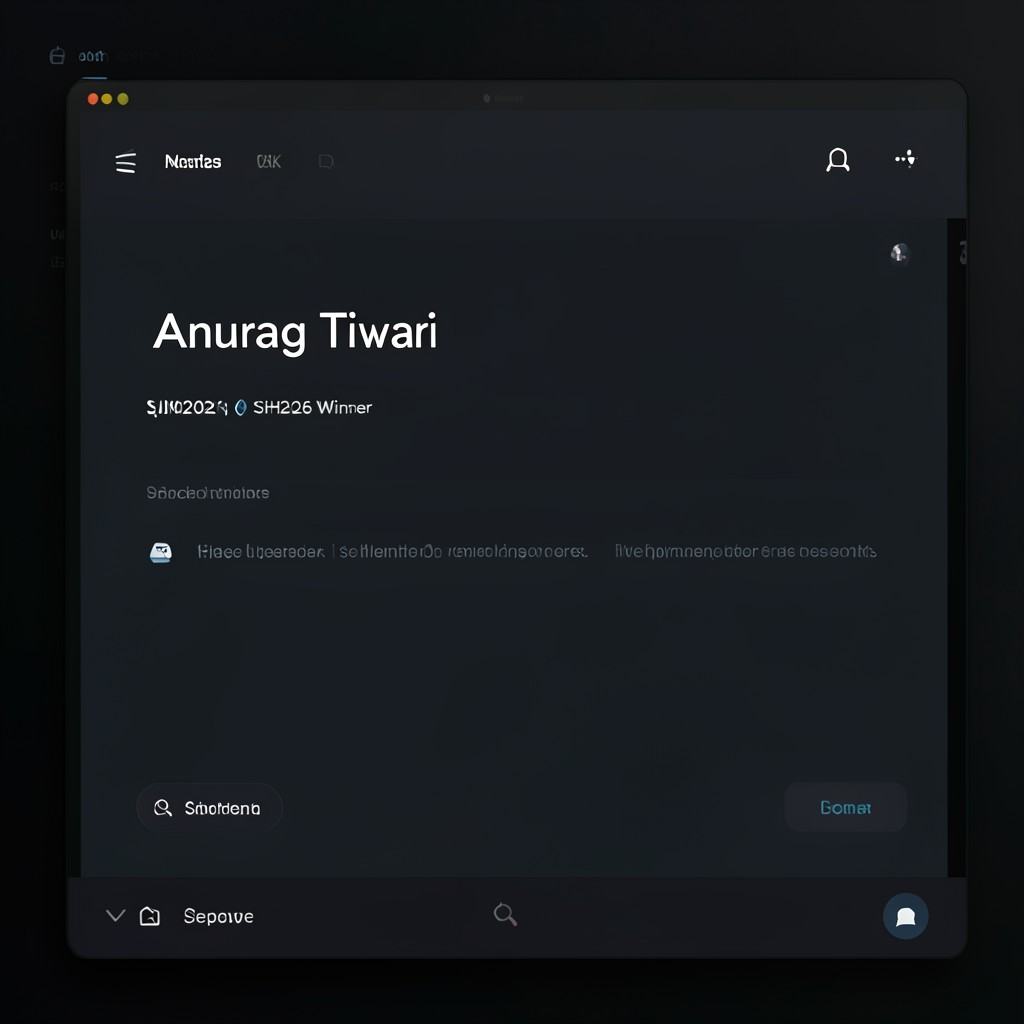

In [41]:
# Re-attempting generation with enhanced error checking and a professional portfolio prompt
portfolio_desc = "Modern Software , Anurag Tiwari, SIH2026 Winner, high-end dark mode interface, minimal design"
generate_ui_ux(portfolio_desc)